In [120]:
import warnings
warnings.filterwarnings('ignore')

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split

In [122]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,rep_inc_dummy,pvi,census_region,dem_scandal_score,rep_scandal_score,Year,Geography,dem_stand,rep_stand,inc_dummy
0,0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton LeFlore,...,1,-14.460266,East South Central,0.0,0.0,2014.0,AL-01,Burton LeFlore,Bradley Byrne,-1
1,1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,...,1,-16.091761,East South Central,0.0,0.0,2014.0,AL-02,Erick Wright,Martha Roby,-1
2,2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse Smith,...,1,-15.311107,East South Central,0.0,0.0,2014.0,AL-03,Jesse Smith,Mike Rogers,-1
3,3,2014,Alabama,AL,False,AL-06,42291.0,135945.0,178449,Mark Lester,...,0,-27.395373,East South Central,0.0,0.0,2014.0,AL-06,Mark Lester,Gary Palmer,0
4,4,2014,Alaska,AK,False,AK-00,114602.0,142572.0,279741,Forrest Dunbar,...,1,-10.647773,Pacific,0.0,1.0,2014.0,AK-00,Forrest Dunbar,Don Young,-1


In [123]:
data.shape

(2331, 55)

In [124]:
data['is_2020'] = data['year'].map(lambda x: 1 if x == 2020 else 0)

In [125]:
data = data.set_index(['year', 'district'])
data.head()

Unnamed: 0    state state_po  special       dem       rep  \
year district                                                              
2014 AL-01              0  Alabama       AL    False   48278.0  103758.0   
     AL-02              1  Alabama       AL    False   54692.0  113103.0   
     AL-03              2  Alabama       AL    False   52816.0  103558.0   
     AL-06              3  Alabama       AL    False   42291.0  135945.0   
     AK-00              4   Alaska       AK    False  114602.0  142572.0   

               totalvotes        dem_cand       rep_cand dem_inc  ...  \
year district                                                     ...   
2014 AL-01         152234  Burton LeFlore  Bradley Byrne   False  ...   
     AL-02         167952    Erick Wright    Martha Roby   False  ...   
     AL-03         156620     Jesse Smith    Mike Rogers   False  ...   
     AL-06         178449     Mark Lester    Gary Palmer   False  ...   
     AK-00         279741  Forrest Dunbar      Don Young   False  ...   

                     pvi       census_region dem_scandal_score  \
year district                                                    
2014 AL-01    -14.460266  East South Central               0.0   
     AL-02    -16.091761  East South Central               0.0   
     AL-03    -15.311107  East South Central               0.0   
     AL-06    -27.395373  East South Central               0.0   
     AK-00    -10.647773             Pacific               0.0   

               rep_scandal_score    Year  Geography       dem_stand  \
year district                                                         
2014 AL-01                   0.0  2014.0      AL-01  Burton LeFlore   
     AL-02                   0.0  2014.0      AL-02    Erick Wright   
     AL-03                   0.0  2014.0      AL-03     Jesse Smith   
     AL-06                   0.0  2014.0      AL-06     Mark Lester   
     AK-00                   1.0  2014.0      AK-00  Forrest Dunbar   

                   rep_stand  inc_dummy  is_2020  
year district                                     
2014 AL-01     Bradley Byrne         -1        0  
     AL-02       Martha Roby         -1        0  
     AL-03       Mike Rogers         -1        0  
     AL-06       Gary Palmer          0        0  
     AK-00         Don Young         -1        0  

[5 rows x 54 columns]

In [126]:
data.columns.values

array(['Unnamed: 0', 'state', 'state_po', 'special', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'dem_poll_avg', 'dem_effn',
       'rep_poll_avg', 'rep_effn', 'seat_number', 'prev_lean',
       'prev2_lean', 'generic_ballot_avg', 'ics', 'cvap_white_pct',
       'cvap_aapi_pct', 'cvap_hisp_pct', 'cvap_black_pct',
       'cvap_natam_pct', 'college', 'demo_cluster', 'district_id',
       'no_dem_cand_flag', 'no_rep_cand_flag', 'dem_inc_any',
       'rep_inc_any', 'dem_inc_dummy', 'rep_inc_dummy', 'pvi',
       'census_region', 'dem_scandal_score', 'rep_scandal_score', 'Year',
       'Geography', 'dem_stand', 'rep_stand', 'inc_dummy', 'is_2020'],
      dtype=object)

In [127]:
data['rep_tot_funds'].isna().any()

np.False_

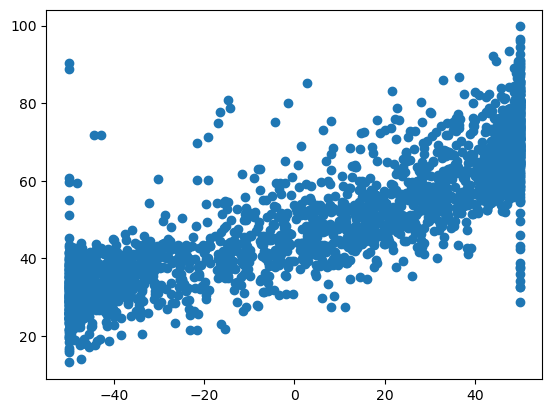

In [128]:
# plt.scatter(np.sqrt(data['dem_effn']) * (data['dem_poll_avg'] - data['rep_poll_avg']), data['dem_pct_2p'])
plt.scatter(data['dem_funds_2p_pct'] - 50, data['dem_pct_2p'])

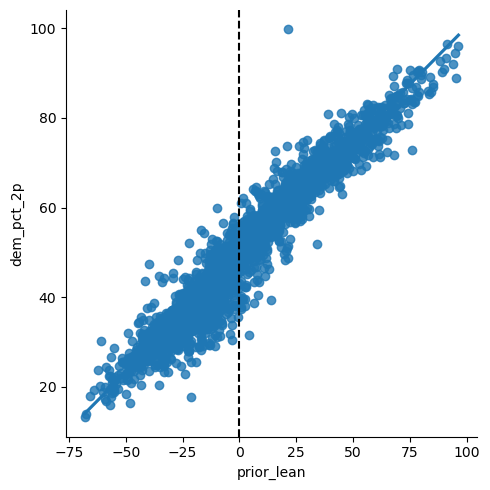

In [140]:
# plt.scatter(data['pvi'] - data['generic_ballot_avg'], data['dem_pct_2p'])
data['prior_lean'] = 2*data['pvi'] - data['generic_ballot_avg']
sns.lmplot(
    data,
    x='prior_lean', y='dem_pct_2p'
)
plt.axvline(0, color='black', linestyle='--')

In [130]:
# sns.scatterplot(
#     data.reset_index(),
#     x='rep_scandal_score', y='dem_pct_2p', hue='year' 
# )

In [131]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2
data['sqrt_effn'] = np.sqrt(data['dem_effn'])
data['poll_margin'] = data['dem_poll_avg'] - data['rep_poll_avg']
data['effnXmargin'] = data['sqrt_effn'] * data['poll_margin']
data['baseline'] = data['pvi']*2 - data['generic_ballot_avg']
data['funds_pct_margin'] = (data['dem_tot_funds'] - data['rep_tot_funds']) / (data['dem_tot_funds'] + data['rep_tot_funds'] + 0.001) * 100

## Preliminary Model Check (Frequentist OLS)

In [132]:
y = data['dem_pct_2p'] - 50
X = data[['baseline',
         'inc_dummy', 'funds_pct_margin', 'dem_scandal_score', 'rep_scandal_score', 'effnXmargin']]
         # 'cvap_black_pct', 'cvap_hisp_pct', 'cvap_natam_pct', 'cvap_aapi_pct',
         #'effnXmargin',]] 
          #'college']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [133]:
X.corr()

,baseline,inc_dummy,funds_pct_margin,dem_scandal_score,rep_scandal_score,effnXmargin
baseline,1.000000,0.750177,0.794526,0.126091,-0.124465,0.003642
inc_dummy,0.750177,1.000000,0.781075,0.122887,-0.156011,0.013905
funds_pct_margin,0.794526,0.781075,1.000000,0.063180,-0.091258,-0.010669
dem_scandal_score,0.126091,0.122887,0.063180,1.000000,-0.018190,0.043344
rep_scandal_score,-0.124465,-0.156011,-0.091258,-0.018190,1.000000,0.007742
effnXmargin,0.003642,0.013905,-0.010669,0.043344,0.007742,1.000000


In [134]:
np.linalg.matrix_rank(X)

np.int64(6)

In [135]:
#X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:             dem_pct_2p   R-squared (uncentered):                   0.951
Model:                            OLS   Adj. R-squared (uncentered):              0.951
Method:                 Least Squares   F-statistic:                              6240.
Date:                Mon, 10 Aug 2026   Prob (F-statistic):                        0.00
Time:                        19:50:01   Log-Likelihood:                         -4262.5
No. Observations:                1561   AIC:                                      8537.
Df Residuals:                    1555   BIC:                                      8569.
Df Model:                           6                                                  
Covariance Type:                  HC1                                                  
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
baseline              0.3958      0.006     71.448      0.000       0.385       0.407
inc_dummy             2.3629      0.179     13.192      0.000       2.012       2.714
funds_pct_margin      0.0326      0.002     13.252      0.000       0.028       0.037
dem_scandal_score    -3.1192      0.927     -3.365      0.001      -4.936      -1.303
rep_scandal_score     1.8480      0.432      4.273      0.000       1.000       2.696
effnXmargin           0.0002   7.81e-05      3.079      0.002    8.73e-05       0.000
==============================================================================
Omnibus:                      298.232   Durbin-Watson:                   1.891
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3896.959
Skew:                           0.488   Prob(JB):                         0.00
Kurtosis:                      10.679   Cond. No.                     1.11e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are heteroscedasticity robust (HC1)
[3] The condition number is large, 1.11e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [136]:
y_test_hat = reg.predict(X_test)
X_test['residuals'] = y_test_hat - y_test
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(13.376009374342647), np.float64(2.814804064581495))

In [137]:
y_test - y_test_hat

year  district
2016  NE-02      -0.547019
2020  OK-05      -0.704338
2022  IL-06      -2.166013
2016  PA-15      -4.046023
2020  PA-17      -1.827696
                    ...   
2014  VA-04      -2.655269
2020  WV-02       2.259315
2014  NE-03      -1.104412
2024  NY-25      -0.904155
      OH-11       2.480777
Length: 770, dtype: float64

In [138]:
X_test.corr()

,baseline,inc_dummy,funds_pct_margin,dem_scandal_score,rep_scandal_score,effnXmargin,residuals
baseline,1.000000,0.738076,0.786629,0.101072,-0.128644,0.013043,-0.099526
inc_dummy,0.738076,1.000000,0.765748,0.105224,-0.156192,0.011803,-0.036990
funds_pct_margin,0.786629,0.765748,1.000000,0.029831,-0.075821,-0.025278,-0.110409
dem_scandal_score,0.101072,0.105224,0.029831,1.000000,-0.013844,0.150702,0.008692
rep_scandal_score,-0.128644,-0.156192,-0.075821,-0.013844,1.000000,-0.001411,-0.003962
effnXmargin,0.013043,0.011803,-0.025278,0.150702,-0.001411,1.000000,0.121985
residuals,-0.099526,-0.036990,-0.110409,0.008692,-0.003962,0.121985,1.000000


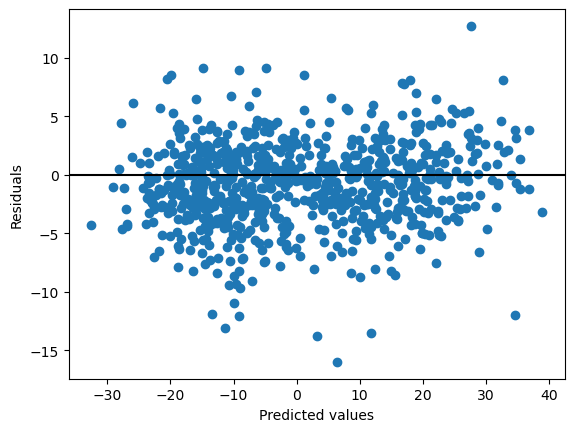

In [139]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [75]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

KeyError: 'prev2_lean'

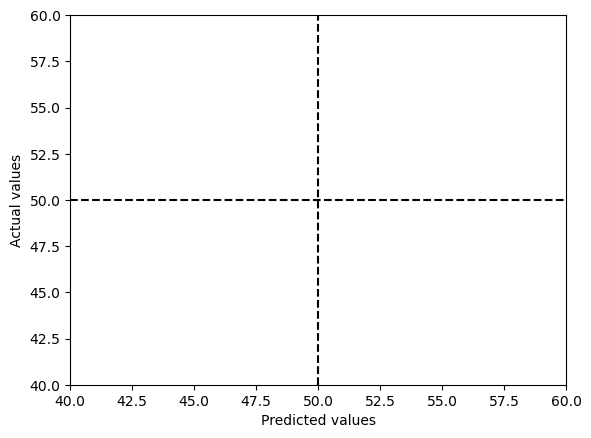

In [77]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Actual values');

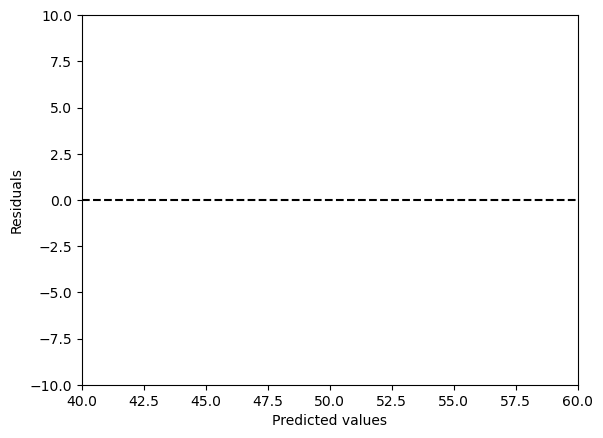

In [78]:
# Actual vs residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(-10, 10)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [59]:
resid = pd.DataFrame(y_test_hat - y_test)
resid = resid.reset_index().rename({0: 'resid'}, axis=1)
resid.head()

,year,district,resid
0,2020,IL-15,1.544257
1,2018,TX-31,-5.173558
2,2018,MD-07,1.652631
3,2018,IN-04,0.361365
4,2022,IN-01,-1.011373


In [76]:
plt.scatter(resid['year'], resid['resid'])
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--');

NameError: name 'resid' is not defined

In [61]:
durbin_watson(reg.resid)

np.float64(1.9784027336335988)